# Manual Day — Quantum Mechanics

Closed-agent, ~60 min. Complete every `# FILL IN` cell, then run the check.

**Four problems — work in order; as many as time permits.** The last two are challenges.

The scaffolds are written with array slicing, but explicit loops over the indices are
equally welcome. Use whichever one you'll get right.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Problem 1 — tunneling through a barrier

Send a wavepacket at a barrier taller than its energy and watch some of it come out
the other side. With $\hbar = 1$, $2m = 1$ the packet's energy is $E = k_0^2 = 144$
and the barrier is $V_0 = 200$, so classically nothing gets through.

Where the update comes from. With $\hbar=1$, $2m=1$ the equation is

$$i\frac{\partial \psi}{\partial t} = -\frac{\partial^2 \psi}{\partial x^2} + V\psi.$$

Write $\psi = R + iI$ and separate the real and imaginary parts:

$$\frac{\partial I}{\partial t} = \frac{\partial^2 R}{\partial x^2} - VR,
\qquad
\frac{\partial R}{\partial t} = -\left(\frac{\partial^2 I}{\partial x^2} - VI\right).$$

Each part is driven by the other, with opposite signs. Put the central difference in
for $\partial_x^2$, step forward by $\Delta t$, and you get what you're about to
write, with $\alpha = \Delta t/\Delta x^2$:

$$\mathrm{Im}\,\psi_j \mathrel{+}= \alpha\big(\mathrm{Re}\,\psi_{j+1}-2\mathrm{Re}\,\psi_j+\mathrm{Re}\,\psi_{j-1}\big) - \Delta t\,V_j\,\mathrm{Re}\,\psi_j,$$

$$\mathrm{Re}\,\psi_j \mathrel{-}= \alpha\big(\mathrm{Im}\,\psi_{j+1}-2\mathrm{Im}\,\psi_j+\mathrm{Im}\,\psi_{j-1}\big) - \Delta t\,V_j\,\mathrm{Im}\,\psi_j.$$

The second line uses the imaginary part you just updated, not the one you started with.

The ordering is the part that's easy to get wrong. Compute both updates from the old
values and it blows up: at this step size the norm reaches $10^{37}$ within a few
thousand steps. Feed the new $I$ into the $R$ update instead and it becomes a
leapfrog, stable, holding the norm to a part in $10^5$. It's the same trick as
updating velocity before position, or sweeping a relaxation in place.

The potential is a square slab sitting in the middle of the box,

$$V(x) = \begin{cases} V_0 & 20 \le x < 20 + a \\[2pt] 0 & \text{otherwise,}\end{cases}$$

with $V_0 = 200$, and the packet starts at $x_0 = 10$ heading right. A square barrier
of width $a$ transmits

$$T = \left[1 + \frac{V_0^2 \sinh^2(\kappa a)}{4E(V_0 - E)}\right]^{-1},
\qquad \kappa = \sqrt{V_0 - E}.$$

Write the stepper, decide how you'll measure what got through, and sweep the width.

**Known answers.** $T = 0.545$, $0.152$, $0.036$ at $a = 0.1$, $0.2$, $0.3$. Tripling
the width costs you a factor of fifteen, because $\sinh(\kappa a)$ grows exponentially.

In [2]:
# GIVEN — the 1D grid and the numbers. hbar = 1, 2m = 1.
lxb, dxb = 40.0, 0.025
nxb = int(lxb/dxb)
xb  = np.arange(nxb+1)*dxb
dtb = dxb**2/20.0
alphab = dtb/dxb**2
k0b, sig2b, x0b = 12.0, 1.0, 10.0
Eb = k0b**2                                  # E = 144, below the barrier
V0b, widths = 200.0, [0.1, 0.2, 0.3]
nstepsb = 40000

In [5]:
# FILL IN: the barrier, the analytic transmission, the stepper, and the sweep.

def barrier(a):
    """Return an array shaped like xb: V0b for 20 <= x < 20 + a, zero elsewhere."""
    V = np.zeros_like(xb)
    V[(xb >= 20) & (xb < 20 + a)] = V0b

    return V

def T_exact(a):
    """Return the analytic transmission for a square barrier of width a.

    Use the formula in the markdown above, with kappa = sqrt(V0b - Eb).
    """
    kappa = np.sqrt(V0b - Eb)
    T = 1 / (1 + (V0b**2*np.sinh(kappa*a)**2) / (4*Eb*(V0b - Eb)))

    return T


def transmitted(a, steps=nstepsb):
    """Step the packet past the barrier; return the fraction of |psi|^2 beyond it."""
    V = barrier(a)
    env = np.exp(-0.5*(xb - x0b)**2/sig2b)
    r, im = env*np.cos(k0b*xb), env*np.sin(k0b*xb)
    r[0] = r[-1] = im[0] = im[-1] = 0.0
    for _ in range(steps):
        im[1:-1] += alphab * (r[2:] - 2*r[1:-1] + r[:-2]) - dtb * V[1:-1] * r[1:-1]        # imaginary part, from r, minus dtb*V*r
        r[1:-1]  -= alphab * (im[2:] - 2*im[1:-1] + im[:-2]) - dtb * V[1:-1] * im[1:-1]        # real part, from the NEW im
        # an index loop instead of these two lines is fine
        r[0] = r[-1] = im[0] = im[-1] = 0.0
    p = r**2 + im**2
    return np.sum(p[xb >= 20 + a]) / np.sum(p)                # the fraction of the probability past the barrier

measured = []

for a in widths:
    T = transmitted(a)
    measured.append(T)  
    
measured               # the transmitted fraction at each width in `widths`

[np.float64(0.5396382235040251),
 np.float64(0.15301421772040477),
 np.float64(0.039303481885428516)]

 a      T measured   T exact   ratio
0.1      0.5396      0.5452     0.99
0.2      0.1530      0.1520     1.01
0.3      0.0393      0.0357     1.10

widening the barrier from 0.1 to 0.3 cuts transmission by 14x
OK


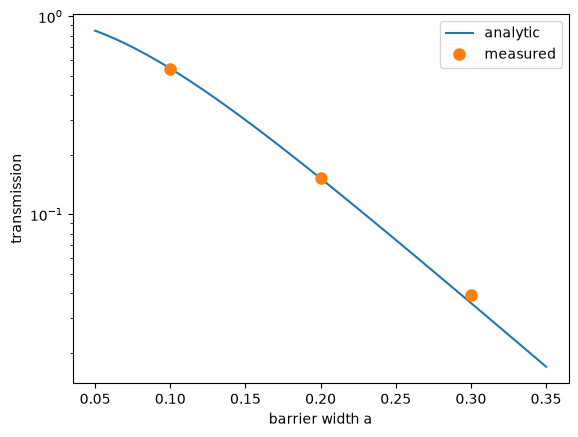

In [6]:
# CHECK — do not edit
print(" a      T measured   T exact   ratio")
for a, t in zip(widths, measured):
    print("%.1f      %.4f      %.4f     %.2f" % (a, t, T_exact(a), t/T_exact(a)))
    assert abs(t/T_exact(a) - 1) < 0.2, "transmission at a = %g is off the analytic value" % a
print("\nwidening the barrier from %.1f to %.1f cuts transmission by %.0fx"
      % (widths[0], widths[-1], measured[0]/measured[-1]))
assert measured[0] > measured[1] > measured[2], "transmission must fall as the barrier widens"
print("OK")

aa = np.linspace(0.05, 0.35, 60)
plt.semilogy(aa, [T_exact(a) for a in aa], "-", label="analytic")
plt.semilogy(widths, measured, "o", ms=8, label="measured")
plt.xlabel("barrier width a"); plt.ylabel("transmission"); plt.legend();

## Problem 2 — the double slit

Now in two dimensions. A wide packet comes in from the left and hits a wall with two
gaps in it. Same equation you've been stepping,

$$i\frac{\partial \psi}{\partial t} = -\nabla^2 \psi + V\psi,$$

with $V = 200$ inside the wall and zero outside. Same staggered scheme as Problem 1,
but the Laplacian now holds two second derivatives,

$$\nabla^2 \psi\big|_{i,j} \approx \frac{\psi_{i+1,j}+\psi_{i-1,j}+\psi_{i,j+1}+\psi_{i,j-1}-4\psi_{i,j}}{\Delta x^2},$$

so it's four neighbors and a $-4$, since each direction brings its own
$-2\psi_{i,j}$. Written out, the two updates are

$$\mathrm{Im}\,\psi_{i,j} \mathrel{+}= \alpha\big(\mathrm{Re}\,\psi_{i+1,j}+\mathrm{Re}\,\psi_{i-1,j}+\mathrm{Re}\,\psi_{i,j+1}+\mathrm{Re}\,\psi_{i,j-1}-4\,\mathrm{Re}\,\psi_{i,j}\big) - \Delta t\,V_{i,j}\,\mathrm{Re}\,\psi_{i,j},$$

$$\mathrm{Re}\,\psi_{i,j} \mathrel{-}= \alpha\big(\mathrm{Im}\,\psi_{i+1,j}+\mathrm{Im}\,\psi_{i-1,j}+\mathrm{Im}\,\psi_{i,j+1}+\mathrm{Im}\,\psi_{i,j-1}-4\,\mathrm{Im}\,\psi_{i,j}\big) - \Delta t\,V_{i,j}\,\mathrm{Im}\,\psi_{i,j},$$

with $\alpha = \Delta t/\Delta x^2$ as before, and the second line using the imaginary
part you just updated.

Slicing is the quick way here, and it's the same five-point neighbor sum from the
Laplace relaxation. Loops are fine if you'd rather see every index. They cost about a
factor of 150 per step, which still only adds up to around 25 seconds for the whole
run, so pick whichever you can get right and move on.

**Known answer.** Run it twice, once with both slits open and once with the lower slit
filled in. With both open, the brightest point on the far screen sits exactly on the
centerline, directly behind the solid block that ought to be casting a shadow. Fill in
one slit and that peak is gone.

In [7]:
# GIVEN — grid and the wall. hbar = 1, 2m = 1, as in Problem 1.
LX, LY, DX = 40.0, 20.0, 0.25
NX, NY = int(LX/DX), int(LY/DX)
DT = DX**2/20.0
ALPHA = DT/DX**2
K0, SIG2 = np.pi*10.5, 2.0**2          # wide packet, so it illuminates both slits
XG, YG = np.meshgrid(np.arange(NX+1)*DX, np.arange(NY+1)*DX)

def wall(both=True):
    """V = 200 in the barrier. Slits are the gaps 1.5 < |y - 10| < 3.5."""
    V = np.zeros((NY+1, NX+1))
    for ix in range(20, 60):                       # barrier spans x = 5 to 14.75
        for iy in range(NY+1):
            d = abs(iy*DX - LY/2)
            blocked = (d > 3.5 or d < 1.5)
            if not both and iy*DX < LY/2:          # plug the lower slit
                blocked = True
            if blocked:
                V[iy, ix] = 200.0
    return V

In [ ]:
# FILL IN: the starting wavepacket, then the two staggered updates.

def packet():
    """The wavepacket at t = 0.

    A Gaussian envelope centred on x = 3, y = LY/2, with variance SIG2 in both
    directions, multiplied by the plane wave exp(i*K0*x) so the packet travels in +x.
    Build it from the grids XG and YG that are already defined above.

    Return two arrays shaped like XG: the real part first, then the imaginary part.
    """
    env = np.exp(-((XG - 3)**2 + (YG - LY/2)**2) / (2*SIG2))
    r = env * np.cos(K0*XG)
    im = env * np.sin(K0*XG)
    return r, im

def evolve(V, steps=1500):
    r, im = packet()
    for _ in range(steps):
        im[1:-1, 1:-1] += (ALPHA * (r[1:-1, 2:] + r[1:-1, :-2] + r[2:, 1:-1] + r[:-2, 1:-1] - 4*r[1:-1, 1:-1]) - DT * V[1:-1, 1:-1] * r[1:-1, 1:-1])
        r[1:-1, 1:-1]  -= (ALPHA * (im[1:-1, 2:] + im[1:-1, :-2] + im[2:, 1:-1] + im[:-2, 1:-1] - 4*im[1:-1, 1:-1]) - DT * V[1:-1, 1:-1] * im[1:-1, 1:-1])  # the same shape, built from the new im
        # loops over i and j instead of these two lines are fine
    return r**2 + im**2      

both slits  midline behind wall 2.91e-03 -> at screen 1.18e-01   brightest point at y = 10.00
one slit    midline behind wall 1.23e-03 -> at screen 2.95e-02   brightest point at y = 2.25

the centerline is 40x brighter at the screen than just behind the wall
OK


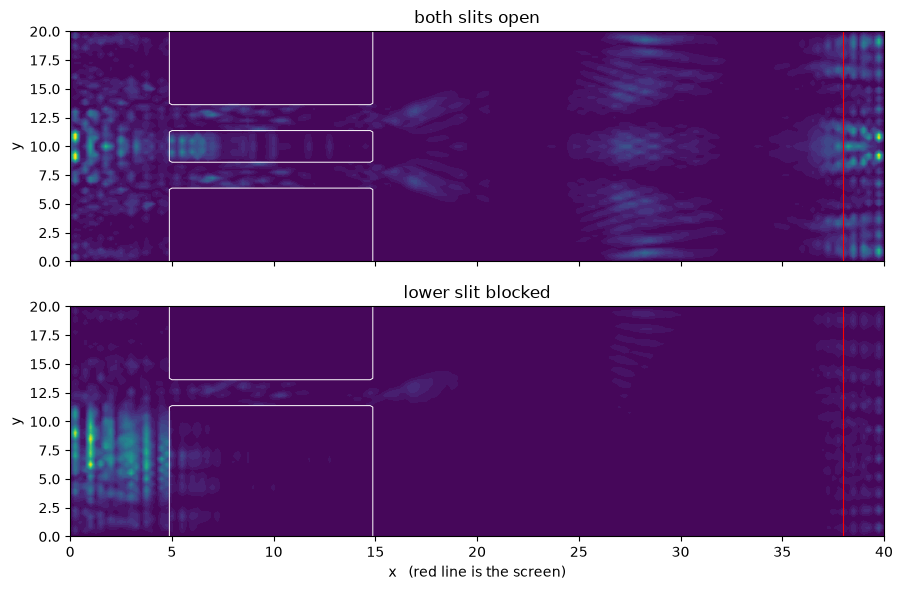

In [21]:
# CHECK — do not edit
p2 = evolve(wall(both=True))
p1 = evolve(wall(both=False))
mid, screen, behind = NY//2, int(38/DX), int(16/DX)
ys = np.arange(NY+1)*DX

for name, p in [("both slits", p2), ("one slit", p1)]:
    col = p[:, screen]
    print("%-11s midline behind wall %.2e -> at screen %.2e   brightest point at y = %.2f"
          % (name, p[mid, behind], p[mid, screen], ys[col.argmax()]))

assert np.abs(p2 - p2[::-1, :]).max()/p2.max() < 1e-10, "two open slits must give a symmetric pattern"
assert p2[:, screen].argmax() == mid, "with both slits the screen maximum must be on the centerline"
assert p1[:, screen].argmax() != mid, "with one slit it must not be"
print("\nthe centerline is %.0fx brighter at the screen than just behind the wall"
      % (p2[mid, screen]/p2[mid, behind]))
print("OK")

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for ax, p, t in [(axes[0], p2, "both slits open"), (axes[1], p1, "lower slit blocked")]:
    ax.contourf(XG, YG, p, 30)
    ax.contour(XG, YG, wall(both=(t == "both slits open")), [100], colors="w", linewidths=0.7)
    ax.axvline(38, color="r", lw=0.8); ax.set_ylabel("y"); ax.set_title(t)
axes[1].set_xlabel("x   (red line is the screen)")
plt.tight_layout();

## Problem 3 — Challenge: free propagation, norm and group velocity

Drop the potential and propagate a free Gaussian packet. There are two things here you
already know the answer to. The total probability $\sum|\psi|^2\,\Delta x$ is conserved
to $O(\Delta t^2)$, so it should barely move over the whole run, and with $\hbar=1$,
$2m=1$ the centroid $\langle x\rangle$ travels at the group velocity $v_g = 2k_0 = 24$.
Your measured centroid speed should land within a few percent of that.

Same staggered scheme as Problem 1, now with $V = 0$:

$$\mathrm{Im}\,\psi_j \mathrel{+}= \alpha\,(\mathrm{Re}\,\psi_{j+1}-2\mathrm{Re}\,\psi_j+\mathrm{Re}\,\psi_{j-1}),\qquad \mathrm{Re}\,\psi_j \mathrel{-}= \alpha\,(\mathrm{Im}\,\psi_{j+1}-2\mathrm{Im}\,\psi_j+\mathrm{Im}\,\psi_{j-1}).$$

In [22]:
# --- 1D grid; free particle, units hbar = 1, 2m = 1 -------------------
lx = 40.0                     # box length (wide, so the packet stays off the walls)
dx = 0.025
nx = int(lx/dx)               # number of intervals
x  = np.arange(nx+1)*dx       # grid points on [0, lx]

dt    = dx**2/20.0            # small time step
alpha = dt/dx**2              # = 0.05

# --- free particle: no potential --------------------------------------
V = np.zeros(nx+1)

# --- initial wavepacket: Gaussian envelope x plane wave ---------------
x0     = 10.0                 # start well left of center; packet moves right
sigma2 = 1.0
k0     = 12.0                 # modest wavenumber -> group velocity v_g = 2*k0
env    = np.exp(-0.5*(x - x0)**2 / sigma2)
psi_r  = env*np.cos(k0*x)
psi_i  = env*np.sin(k0*x)
psi_r[0] = psi_r[-1] = 0.0    # walls
psi_i[0] = psi_i[-1] = 0.0

nsteps       = 24000
record_every = 2000

# --- helpers ----------------------------------------------------------
def prob():
    return psi_r**2 + psi_i**2

def norm():
    return np.sum(prob())*dx           # total probability

def centroid():
    p = prob()
    return np.sum(x*p)/np.sum(p)        # <x> of |psi|^2

def plot_prob():
    plt.plot(x, prob())
    plt.xlabel("x"); plt.ylabel("|psi|^2"); plt.show()

In [23]:
# FILL IN: staggered (Visscher) leapfrog time-stepping loop, free particle (V = 0).
# Order is load-bearing: update the IMAGINARY part first (from the current real part),
# then the REAL part from the NEW imaginary part. Clamp the walls to 0 each step.
# Record norm and centroid every `record_every` steps.

times, norms, centroids = [], [], []

for n in range(nsteps):
    psi_i[1:-1] += alpha * (psi_r[2:] - 2*psi_r[1:-1] + psi_r[:-2])# FILL IN: update psi_i[1:-1] from psi_r  (imaginary part, FIRST)
    psi_r[1:-1] -= alpha * (psi_i[2:] - 2*psi_i[1:-1] + psi_i[:-2])# FILL IN: update psi_r[1:-1] from the NEW psi_i  (real part, SECOND)

    psi_r[0] = psi_r[-1] = 0.0
    psi_i[0] = psi_i[-1] = 0.0

    if n % record_every == 0:
        times.append(n*dt); norms.append(norm()); centroids.append(centroid())

times.append(nsteps*dt); norms.append(norm()); centroids.append(centroid())


In [24]:
# --- CHECK: norm conservation and group velocity (given) --------------
print(f"norm start = {norms[0]:.6f}")
print(f"norm end   = {norms[-1]:.6f}")
print(f"relative norm drift = {abs(norms[-1]-norms[0])/norms[0]:.2e}")

v_measured = (centroids[-1] - centroids[0]) / (times[-1] - times[0])
v_group    = 2*k0
print(f"\nmeasured centroid velocity = {v_measured:.3f}")
print(f"group velocity 2*k0        = {v_group:.3f}")
print(f"relative error = {abs(v_measured-v_group)/v_group:.1%}")


norm start = 1.772454
norm end   = 1.772463
relative norm drift = 5.09e-06

measured centroid velocity = 23.637
group velocity 2*k0        = 24.000
relative error = 1.5%


## Problem 4 — Challenge: a stationary state that stays put

Put the ground state of the infinite square well on the grid and evolve it. In a box
$[0,L]$ with walls at both ends and $H=-\partial_x^2$, the eigenstates and energies are

$$\psi_n(x)=\sin\frac{n\pi x}{L},\qquad E_n=\left(\frac{n\pi}{L}\right)^2 .$$

Start from $n=1$, so $\psi_r=\sin(\pi x/L)$ and $\psi_i=0$. A stationary state only
picks up a phase, $\psi(x,t)=\psi_n(x)\,e^{-iE_n t}$, so you know what has to happen.
The density $|\psi|^2$ shouldn't move at all, and the real part at the midpoint should
oscillate as $\cos(E_n t)$ with period $2\pi/E_n$.

Same scheme again, with $V=0$.

In [ ]:
# --- Problem 4 setup (GIVEN): n = 1 eigenstate of the infinite square well ---
# Units hbar = 1, 2m = 1, so H = -d^2/dx^2 and E_n = (n*pi/L)^2.
L  = 1.0                       # box [0, L]; walls pin psi = 0 at both ends
dx = 0.02
nx = int(round(L/dx))          # number of intervals
x  = np.arange(nx+1)*dx        # grid points on [0, L]

dt    = dx**2/20.0             # small time step (same CFL-safe choice as Problem 1)
alpha = dt/dx**2               # = 0.05

V = np.zeros(nx+1)             # infinite square well: V = 0 inside, walls enforced by pinning

n_mode = 1                                # ground state
psi_r  = np.sin(n_mode*np.pi*x/L)         # exact spatial eigenstate (real)
psi_i  = np.zeros(nx+1)                    # start with zero imaginary part
psi_r[0] = psi_r[-1] = 0.0                # walls
psi_i[0] = psi_i[-1] = 0.0

E_n    = (n_mode*np.pi/L)**2   # eigen-energy (hbar = 1, 2m = 1)
T      = 2*np.pi/E_n           # period of the phase factor e^{-i E_n t}
nsteps = int(round(T/dt))      # ~ one full period
mid    = nx//2                 # index of the box midpoint x = L/2

def prob():
    return psi_r**2 + psi_i**2

def norm():
    return np.sum(prob())*dx   # total probability

In [ ]:
# FILL IN: staggered (Visscher) leapfrog update for the n = 1 eigenstate (V = 0).
# Same scheme and ordering as Problem 1: update the IMAGINARY part first (from the
# current real part), then the REAL part from the NEW imaginary part. Clamp walls to 0.
# Each step, record the time, the norm, and psi_r at the midpoint `mid`.

times, norms, psi_mid = [], [], []

for step in range(nsteps):
    # FILL IN: update psi_i[1:-1] from psi_r          (imaginary part, FIRST)
    # FILL IN: update psi_r[1:-1] from the NEW psi_i   (real part, SECOND)

    psi_r[0] = psi_r[-1] = 0.0
    psi_i[0] = psi_i[-1] = 0.0

    times.append(step*dt)
    norms.append(norm())
    psi_mid.append(psi_r[mid])

times   = np.array(times)
norms   = np.array(norms)
psi_mid = np.array(psi_mid)

In [ ]:
# --- CHECK: stationary density + phase oscillation at the midpoint (given) ---
drift = (norms.max() - norms.min())/norms.mean()
print(f"norm min / max      = {norms.min():.6f} / {norms.max():.6f}")
print(f"relative variation  = {drift:.2e}   (|psi|^2 essentially constant)")

# measure the period of psi_r(mid, t) from its sign changes (each = a half period)
crossings = np.where(np.sign(psi_mid[:-1]) != np.sign(psi_mid[1:]))[0]
# linear-interpolate each crossing time for sub-step accuracy
tc = times[crossings] + dt*psi_mid[crossings]/(psi_mid[crossings] - psi_mid[crossings+1])
T_measured = 2*np.mean(np.diff(tc))

print(f"\nmeasured period     = {T_measured:.5f}")
print(f"expected 2*pi/E_n   = {T:.5f}")
print(f"relative error      = {abs(T_measured - T)/T:.1%}")